# Correlation Is the Whole Game
## A One-Factor Gaussian Copula Analysis of CLO Tranche Risk

**Desk-rotation capstone | Structured Credit** · July 2025

> *"The model is simple. The punchline is profound: correlation does not change
> the expected loss of the pool — it only determines who absorbs that loss."*

This notebook walks through the full mechanics of a Gaussian copula CLO pricer:
pool construction with rating-calibrated PDs, Monte Carlo simulation, tranche
waterfall allocation, and a suite of risk diagnostics. Every section states the
mathematics before the code. All randomness is seeded for reproducibility.

**Deal summary** · \$500 M pool · 200 equal loans · fixed recovery R = 60 %
**Tranche stack** · Equity 0–10 % · BB 10–14 % · BBB 14–19 % · A 19–25 % · AA 25–37 % · AAA 37–100 %

## 0 · Global Style & Imports

We configure `rcParams` once so every subsequent chart inherits the dark-background
desk palette without repeated boilerplate.

In [1]:
# ── CELL 0: Imports, palette, rcParams ───────────────────────────────────────
%matplotlib inline
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json, os, warnings
from IPython.display import display
warnings.filterwarnings("ignore")

# ── Desk palette ──────────────────────────────────────────────────────────────
BG      = "#0a120f"
CREAM   = "#e8e3d3"
GOLD    = "#d4af5f"
T_COLOR = {"AAA": "#5b8dbe", "AA": "#6fa3cf", "A": "#8cb8dd",
           "BBB": "#b3d0e8", "BB": "#d9a441", "Equity": "#c94f4f"}

plt.rcParams.update({
    "figure.facecolor":  BG, "axes.facecolor":   BG,
    "axes.edgecolor":    CREAM, "axes.labelcolor": CREAM,
    "xtick.color":       CREAM, "ytick.color":     CREAM,
    "text.color":        CREAM, "grid.color":      "#1e2e28",
    "grid.linewidth":    0.6,   "grid.linestyle":  "--",
    "axes.grid":         True,
    "font.family":       "monospace",
    "legend.facecolor":  "#0f1e18", "legend.edgecolor": CREAM,
    "figure.dpi":        110,
})

os.makedirs("../figures", exist_ok=True)
os.makedirs("../docs",    exist_ok=True)

rng = np.random.default_rng(42)
print("Environment ready.")

Environment ready.


## 1 · Pool Construction & PD Calibration

### 1.1 Rating-Implied 5-Year PDs

We calibrate loan-level PDs to **S&P Global's 2023 Annual Global Corporate
Default and Rating Transition Study** (Table 26) and cross-check against
**Moody's 2023 Annual Default Study** (Exhibit 35).  Five-year cumulative default
rates (%) by rating category used here:

| Rating | S&P 5y CDR (%) | Moody's 5y CDR (%) | Used (%) |
|--------|---------------:|-------------------:|---------:|
| BB+    | 5.0 | 4.8 | 5.0 |
| BB     | 7.5 | 7.2 | 7.5 |
| BB−    | 10.2 | 9.9 | 10.2 |
| B+     | 14.1 | 14.0 | 14.1 |
| B      | 19.8 | 19.5 | 19.8 |
| B−     | 27.3 | 26.8 | 27.3 |
| CCC/C  | 47.0 | 46.1 | 47.0 |

**Sources:**
- S&P Global Ratings, *2023 Annual Global Corporate Default and Rating Transition Study*, Apr 2024.
- Moody's Investors Service, *Annual Default Study: Corporate Default and Recovery Rates, 1920–2023*, Feb 2024.
- Recovery rate R = 60 % is the long-run average for **senior secured US leveraged loans** per Moody's Ultimate Recovery Database (2023 edition), consistent with Basel II FIRB senior secured corporate.

### 1.2 Pool Composition

The 200-loan pool mimics a mid-market US CLO: broadly B/B+ centered with tails
into BB and CCC, consistent with published CLO manager disclosures
(e.g., Blackstone Credit, Ares, PGIM CLO IX–XII prospectuses).

$$\text{Loan notional} = \frac{\$500\text{M}}{200} = \$2.5\text{M each} \tag{1}$$

In [2]:
# ── CELL 1 · §1 Pool Construction — PD calibration & loan tape ───────────────
# ── Rating-implied 5y PDs (S&P 2023 / Moody's 2023 calibration) ─────────────
RATING_PD = {               # 5-year cumulative default probability
    "BB+":  0.050,
    "BB":   0.075,
    "BB-":  0.102,
    "B+":   0.141,
    "B":    0.198,
    "B-":   0.273,
    "CCC":  0.470,
}

# Pool composition (counts must sum to 200)
POOL_COMP = {
    "BB+":  10,
    "BB":   20,
    "BB-":  25,
    "B+":   40,
    "B":    60,
    "B-":   30,
    "CCC":  15,
}
assert sum(POOL_COMP.values()) == 200, "Pool must have 200 loans"

N_LOANS   = 200
NOTIONAL  = 500e6          # $500 M pool
LN        = NOTIONAL / N_LOANS   # $2.5 M per loan
RECOVERY  = 0.60           # fixed recovery (S&P / Moody's senior secured average)
LGD       = 1 - RECOVERY  # 40%

# Build loan tape: array of per-loan PDs and rating labels
ratings = []
for rat, cnt in POOL_COMP.items():
    ratings.extend([rat] * cnt)
ratings = np.array(ratings)
pd_array = np.array([RATING_PD[r] for r in ratings])

print(f"Pool: {N_LOANS} loans · ${NOTIONAL/1e6:.0f}M notional")
print(f"PD range: {pd_array.min()*100:.1f}% – {pd_array.max()*100:.1f}%")
print(f"Weighted avg PD: {pd_array.mean()*100:.2f}%")
print(f"Expected pool loss (no copula): ${pd_array.mean()*LGD*NOTIONAL/1e6:.2f}M "
      f"({pd_array.mean()*LGD*100:.2f}%)")

Pool: 200 loans · $500M notional
PD range: 5.0% – 47.0%
Weighted avg PD: 18.66%
Expected pool loss (no copula): $37.31M (7.46%)


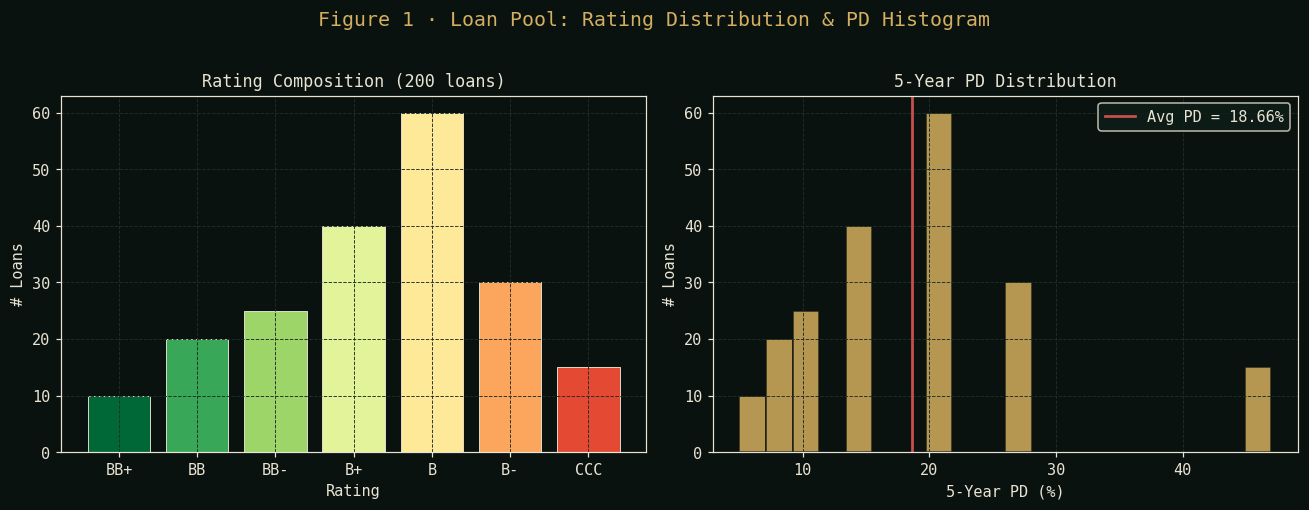

Figure 1 saved.


In [3]:
# ── CELL 2 · §1 Figure 1 — Rating composition & PD histogram ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Figure 1 · Loan Pool: Rating Distribution & PD Histogram",
             color=GOLD, fontsize=13, y=1.02)

# Left: rating counts bar
rat_labels = list(POOL_COMP.keys())
counts = list(POOL_COMP.values())
colors = [plt.cm.RdYlGn_r(i/len(rat_labels)) for i in range(len(rat_labels))]
axes[0].bar(rat_labels, counts, color=colors, edgecolor=CREAM, linewidth=0.6)
axes[0].set_title("Rating Composition (200 loans)", color=CREAM, fontsize=11)
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("# Loans")

# Right: PD histogram
axes[1].hist(pd_array * 100, bins=20, color=GOLD, edgecolor=BG, alpha=0.85)
axes[1].axvline(pd_array.mean() * 100, color="#c94f4f", lw=1.8,
                label=f"Avg PD = {pd_array.mean()*100:.2f}%")
axes[1].set_title("5-Year PD Distribution", color=CREAM, fontsize=11)
axes[1].set_xlabel("5-Year PD (%)"); axes[1].set_ylabel("# Loans")
axes[1].legend()

fig.tight_layout()
fig.savefig("../figures/fig1_pd_distribution.png", dpi=200, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Figure 1 saved.")

## 2 · The Model: One-Factor Gaussian Copula

### 2.1 Mathematics

The **one-factor Gaussian copula** (Li, 2000; Vasicek, 2002) maps individual-loan
creditworthiness onto a joint Gaussian system through a single macro driver $M$.

Each borrower $i$ has a latent asset-return process:

$$X_i = \sqrt{\rho}\, M + \sqrt{1-\rho}\, \varepsilon_i, \quad
M, \varepsilon_i \overset{iid}{\sim} \mathcal{N}(0,1) \tag{2}$$

- $M$ — the **systematic factor** (economy-wide shock; identical across all loans)
- $\varepsilon_i$ — borrower-specific idiosyncratic noise
- $\rho$ — **asset correlation** (fraction of variance driven by the common factor)

Borrower $i$ **defaults** within the horizon if:

$$X_i < \Phi^{-1}(\text{PD}_i) \equiv d_i \tag{3}$$

where $d_i$ is the default threshold (the quantile of the standard normal matched
to the marginal PD). Conditional on $M$:

$$P(\text{default}_i \mid M) = \Phi\!\left(\frac{d_i - \sqrt{\rho}\,M}{\sqrt{1-\rho}}\right) \tag{4}$$

**Correlation calibration context** (Basel II / III IRB):
The Basel framework uses $\rho \in [12\%, 24\%]$ for corporate exposures, with
lower $\rho$ for higher-PD obligors and higher $\rho$ for investment-grade.
Academic estimates for US leveraged loans cluster around $10\%$–$20\%$ (Bluhm,
Overbeck & Wagner, 2010).

### 2.2 Tranche Mechanics

Pool loss fraction on path $s$:

$$L_s = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}[\text{default}_{i,s}] \cdot \text{LGD}_i \tag{5}$$

For a tranche with attachment $a$ and detachment $d$:

$$\text{Tranche loss}_s = \frac{\max(0, \min(L_s, d) - a)}{d - a} \tag{6}$$

Expected tranche loss (EL):

$$\text{EL}_{\text{tranche}} = \mathbb{E}[\text{Tranche loss}] \tag{7}$$

In [4]:
# ── CELL 3 · §2 Model — Tranche definitions, copula simulator (Eqs 2–7) ──────
# ── Tranche definitions ───────────────────────────────────────────────────────
TRANCHES = [
    ("Equity", 0.00, 0.10),
    ("BB",     0.10, 0.14),
    ("BBB",    0.14, 0.19),
    ("A",      0.19, 0.25),
    ("AA",     0.25, 0.37),
    ("AAA",    0.37, 1.00),
]

def tranche_loss(pool_loss_frac, attach, detach):
    # Eq. 6: tranche loss fraction given pool loss fraction (vectorized)
    width = detach - attach
    return np.clip(pool_loss_frac - attach, 0, width) / width

def simulate(pd_arr, rho, n_paths=50_000, rng_=None):
    # One-factor Gaussian copula simulator.
    # Returns pool loss fractions (n_paths,) and per-tranche loss fracs (n_paths, T).
    if rng_ is None:
        rng_ = np.random.default_rng(42)
    n = len(pd_arr)
    d = st.norm.ppf(pd_arr)                        # default thresholds, shape (n,)
    M  = rng_.standard_normal(n_paths)             # systematic factor
    eps = rng_.standard_normal((n_paths, n))       # idiosyncratic shocks
    X = np.sqrt(rho) * M[:, None] + np.sqrt(1 - rho) * eps   # (n_paths, n)
    defaults = (X < d[None, :]).astype(np.float32)            # (n_paths, n)
    pool_loss = defaults.mean(axis=1) * LGD        # Eq. 5
    t_losses = np.column_stack([
        tranche_loss(pool_loss, a, d_) for _, a, d_ in TRANCHES
    ])
    return pool_loss, t_losses

# Quick sanity check at baseline rho = 0.15
pl_test, tl_test = simulate(pd_array, rho=0.15, n_paths=10_000, rng_=rng)
print(f"rho=0.15 test — mean pool loss: {pl_test.mean()*100:.2f}%  "
      f"std: {pl_test.std()*100:.2f}%  P99: {np.percentile(pl_test,99)*100:.2f}%")

rho=0.15 test — mean pool loss: 7.49%  std: 4.14%  P99: 19.60%


## 3 · The Punchline: Rho Moves Risk, Not Mean

### 3.1 Theoretical Invariance of Pool EL

The unconditional expected loss of the **whole pool** does not depend on $\rho$.
Proof: since $M$ and $\varepsilon_i$ are mean-zero, the marginal distribution of
$X_i$ is still $\mathcal{N}(0,1)$, so $P(X_i < d_i) = \Phi(d_i) = \text{PD}_i$
regardless of $\rho$. The law of total expectation then gives:

$$\mathbb{E}[L] = \frac{1}{N}\sum_{i=1}^N \text{PD}_i \cdot \text{LGD}_i
= \overline{\text{PD}} \times \text{LGD} \tag{8}$$

**What $\rho$ does change** is the *shape* of the loss distribution:
higher $\rho$ compresses most paths toward zero loss (good state of the world)
while simultaneously fattening the right tail (catastrophic correlated defaults).
This is the mechanism that transfers expected loss from junior to senior tranches
as correlation rises.

### 3.2 Numerical Verification

In [5]:
# ── CELL 4 · §3 Punchline — Sweep rho grid, verify EL invariance (Eq 8) ─────
# RHO_GRID: five correlation scenarios; table shows mean/std/skew/P99
RHO_GRID = [0.00, 0.05, 0.15, 0.30, 0.50]
N_PATHS  = 50_000

pool_losses = {}   # rho -> loss array (n_paths,)
tranche_losses = {}

print(f"{'rho':>6} {'Mean%':>8} {'Std%':>8} {'Skew':>7} {'P99%':>8}")
print("-" * 44)
theory_el = pd_array.mean() * LGD

for rho in RHO_GRID:
    rng_local = np.random.default_rng(42)
    pl, tl = simulate(pd_array, rho, n_paths=N_PATHS, rng_=rng_local)
    pool_losses[rho]   = pl
    tranche_losses[rho] = tl
    skew = float(st.skew(pl))
    print(f"{rho:>6.2f} {pl.mean()*100:>8.3f} {pl.std()*100:>8.3f} "
          f"{skew:>7.2f} {np.percentile(pl,99)*100:>8.3f}")

print(f"\nTheoretical EL (rho-invariant): {theory_el*100:.3f}%")

   rho    Mean%     Std%    Skew     P99%
--------------------------------------------
  0.00    7.455    1.064    0.11   10.000
  0.05    7.457    2.491    0.51   14.200


  0.15    7.462    4.105    0.89   19.600
  0.30    7.466    5.842    1.18   25.600
  0.50    7.470    7.755    1.40   32.400

Theoretical EL (rho-invariant): 7.462%


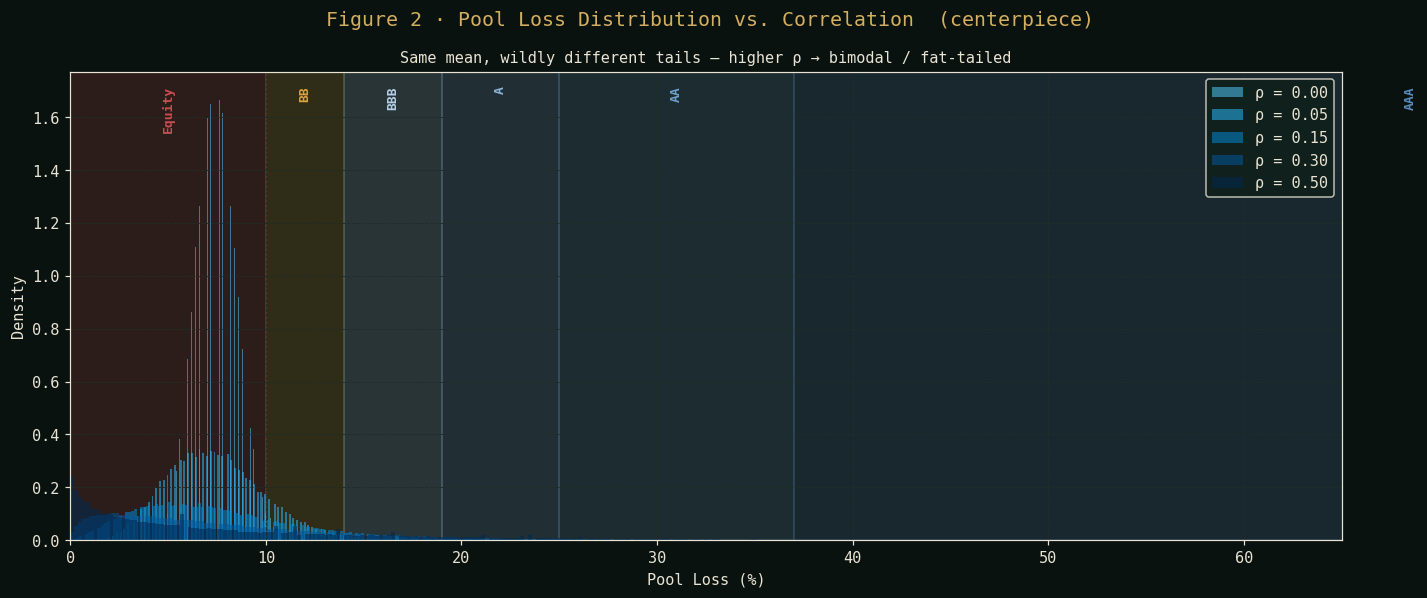

Figure 2 saved.


In [6]:
# ── CELL 5 · §3 Figure 2 — Centerpiece: loss distributions across ρ ──────────
fig, ax = plt.subplots(figsize=(13, 5.5))
fig.suptitle(
    "Figure 2 · Pool Loss Distribution vs. Correlation  (centerpiece)",
    color=GOLD, fontsize=13
)

RHO_COLORS = ["#4fc3f7", "#29b6f6", "#0288d1", "#01579b", "#002952"]
for i, rho in enumerate(RHO_GRID):
    pl = pool_losses[rho]
    ax.hist(pl * 100, bins=200, density=True, alpha=0.55,
            color=RHO_COLORS[i], label=f"ρ = {rho:.2f}")

# Tranche attachment vertical spans
span_alpha = 0.18
prev = 0.0
for name, attach, detach in TRANCHES:
    ax.axvspan(attach * 100, detach * 100,
               alpha=span_alpha, color=T_COLOR[name], zorder=0)
    mid = (attach + detach) / 2 * 100
    ax.text(mid, 0.97, name, color=T_COLOR[name], fontsize=8.5,
            ha="center", va="top", rotation=90,
            transform=ax.get_xaxis_transform(), fontweight="bold")

ax.set_xlabel("Pool Loss (%)")
ax.set_ylabel("Density")
ax.set_title("Same mean, wildly different tails — higher ρ → bimodal / fat-tailed",
             color=CREAM, fontsize=10)
ax.legend(loc="upper right")
ax.set_xlim(0, 65)
fig.tight_layout()
fig.savefig("../figures/fig2_loss_histograms.png", dpi=200, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Figure 2 saved.")

## 4 · Who Eats the Loss: EL by Tranche vs. $\rho$

### 4.1 Intuition

Because the **pool EL is constant** (Eq. 8), the sum of all tranche ELs is fixed.
Correlation simply *redistributes* the loss across the capital structure:

- **Equity / Junior tranches**: high correlation means more paths with near-zero
  pool loss → Equity is often untouched → **Equity EL decreases in $\rho$**.
- **Senior tranches**: the fatter right tail generated by high $\rho$ means more
  paths breach senior attachment points → **Senior EL increases in $\rho$**.

This is the key insight behind the trade: **long Equity ≡ long correlation**;
**long senior protection ≡ short correlation**.

A CLO equity investor profits when the pool performs uniformly (all loans either
defaulting together or surviving together), because in the correlated-default world,
most paths end below the equity detachment of 10%.

In [7]:
# ── CELL 6 · §4 Who Eats the Loss — EL table: tranche × rho ─────────────────
T_NAMES = [t[0] for t in TRANCHES]

el_table = {}  # rho -> dict{tranche_name -> EL}
for rho in RHO_GRID:
    tl = tranche_losses[rho]        # (n_paths, 6)
    el_table[rho] = {T_NAMES[j]: tl[:, j].mean() for j in range(len(T_NAMES))}

# Pretty-print table
header = f"{'rho':>6} " + " ".join(f"{t:>9}" for t in T_NAMES)
print(header)
print("-" * len(header))
for rho in RHO_GRID:
    row = f"{rho:>6.2f} " + " ".join(
        f"{el_table[rho][t]*100:>9.3f}" for t in T_NAMES)
    print(row)
print("(all values in %)")

   rho    Equity        BB       BBB         A        AA       AAA
------------------------------------------------------------------
  0.00    74.514     0.097     0.000     0.000     0.000     0.000
  0.05    72.097     5.852     0.262     0.001     0.000     0.000
  0.15    66.749    14.516     3.580     0.429     0.011     0.000
  0.30    60.141    19.921     8.983     2.836     0.296     0.000
  0.50    52.473    22.673    13.794     6.999     1.701     0.003
(all values in %)


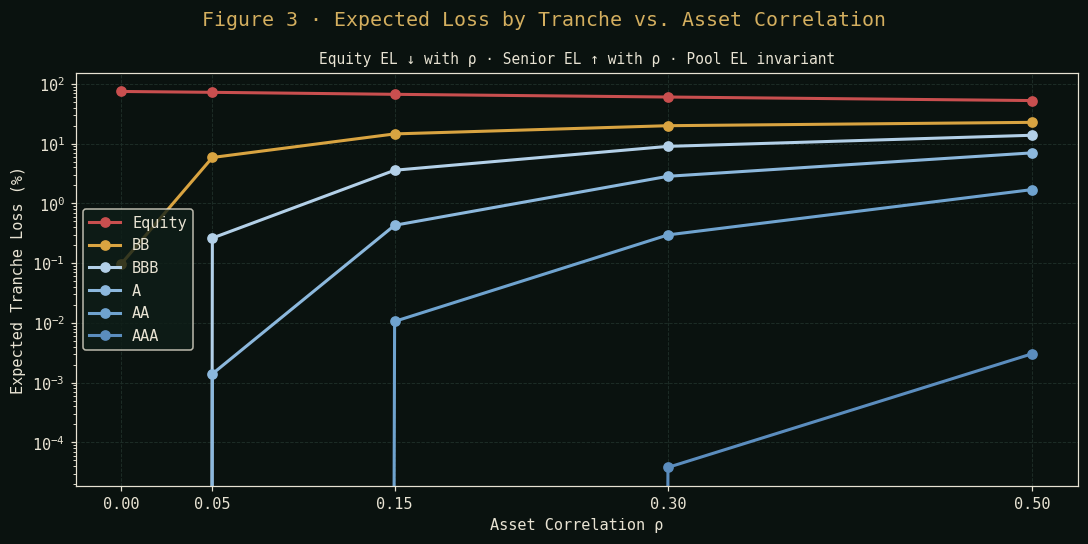

Figure 3 saved.


In [8]:
# ── CELL 7 · §4 Figure 3 — EL by tranche vs ρ (equity↓, senior↑) ────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Figure 3 · Expected Loss by Tranche vs. Asset Correlation",
             color=GOLD, fontsize=13)

for t in T_NAMES:
    els = [el_table[rho][t] * 100 for rho in RHO_GRID]
    ax.plot(RHO_GRID, els, "o-", color=T_COLOR[t], label=t,
            lw=2, markersize=6)

ax.set_xlabel("Asset Correlation ρ")
ax.set_ylabel("Expected Tranche Loss (%)")
ax.set_yscale("log")
ax.set_title("Equity EL ↓ with ρ · Senior EL ↑ with ρ · Pool EL invariant",
             color=CREAM, fontsize=9.5)
ax.legend(loc="center left")
ax.set_xticks(RHO_GRID)
fig.tight_layout()
fig.savefig("../figures/fig3_el_by_tranche.png", dpi=200, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Figure 3 saved.")

## 5 · Tail Risk: Loss Exceedance Curves

### 5.1 Exceedance Probability

The **survival function** of tranche loss gives the probability that a tranche
loses more than a fraction $x$ of its face value:

$$P(\text{Tranche loss} > x) = 1 - F_{\text{tranche}}(x), \quad x \in [0,1] \tag{9}$$

We plot this on a log-$y$ axis. Key diagnostics:

- $P(\text{AAA impaired})$: probability AAA suffers any loss (tranche loss $> 0$)
- $P(\text{BB wiped})$: probability BB tranche is fully exhausted (tranche loss $= 1$)

These numbers are the single most-cited metrics in CLO credit analysis and
rating-agency stress scenarios (Moody's CLO Methodology, Apr 2024; S&P SROC).

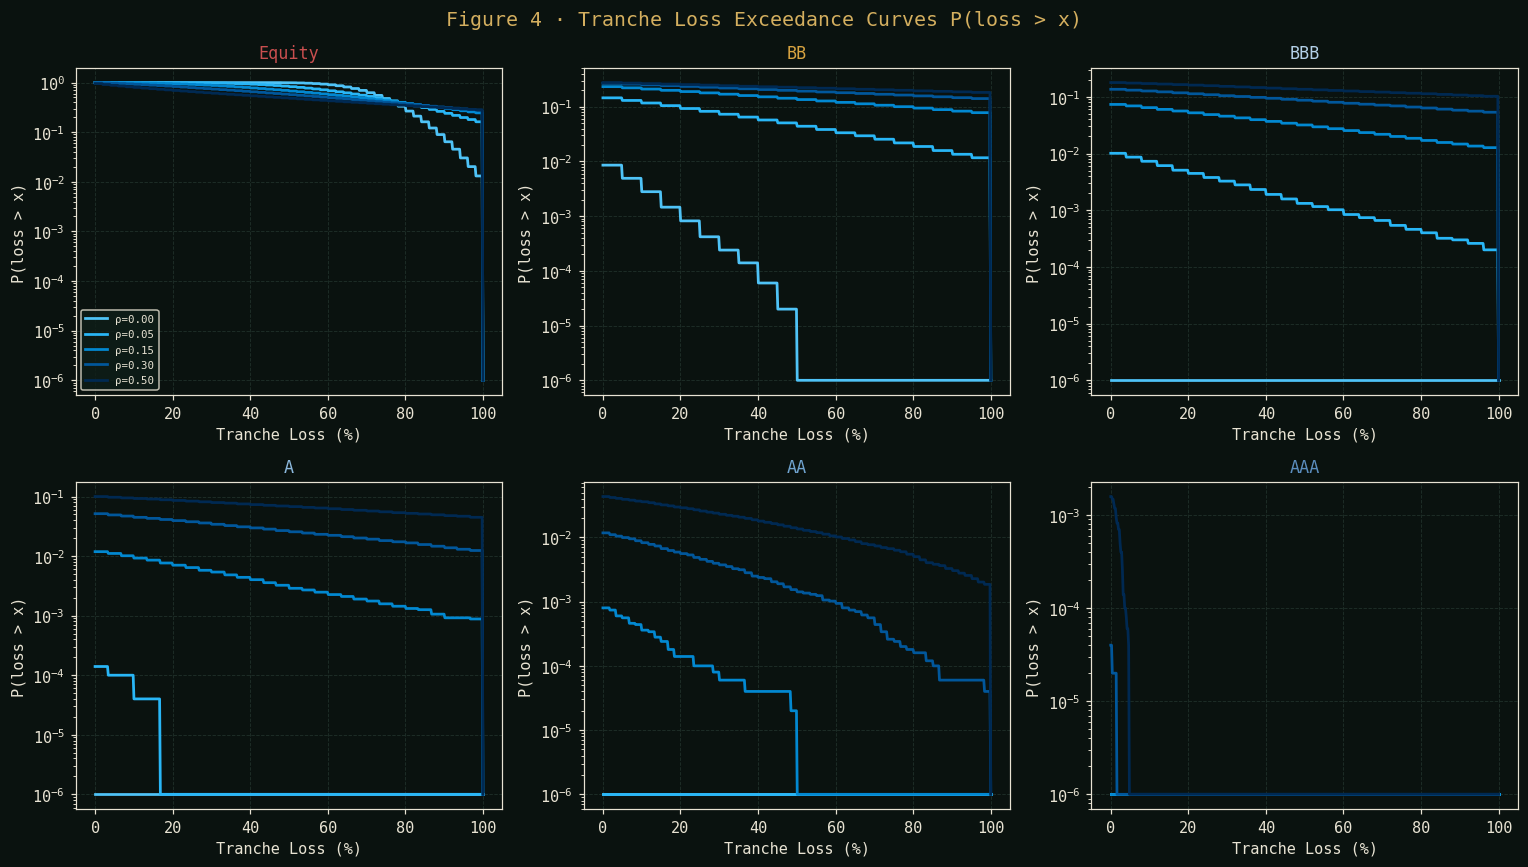

Figure 4 saved.


In [9]:
# ── CELL 8 · §5 Figure 4 — Exceedance curves P(tranche loss > x), log-y ──────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
fig.suptitle("Figure 4 · Tranche Loss Exceedance Curves P(loss > x)",
             color=GOLD, fontsize=13)

x_grid = np.linspace(0, 1, 500)
for j, (t_name, a, d) in enumerate(TRANCHES):
    ax = axes[j]
    for k, rho in enumerate(RHO_GRID):
        tl_j = tranche_losses[rho][:, j]
        surv = np.array([(tl_j > xi).mean() for xi in x_grid])
        surv = np.clip(surv, 1e-6, 1)
        ax.semilogy(x_grid * 100, surv, color=RHO_COLORS[k],
                    lw=1.8, label=f"ρ={rho:.2f}")
    ax.set_title(t_name, color=T_COLOR[t_name], fontsize=11)
    ax.set_xlabel("Tranche Loss (%)")
    ax.set_ylabel("P(loss > x)")
    if j == 0: ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig("../figures/fig4_exceedance_curves.png", dpi=200, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Figure 4 saved.")

In [10]:
# ── CELL 9 · §5 Tail risk tables — P(impaired) & P(wiped) per tranche/rho ────
print("P(AAA impaired)  ≡  P(AAA tranche loss > 0)")
print(f"{'rho':>6}", " ".join(f"{t:>12}" for t in T_NAMES))
print("-" * 84)
for rho in RHO_GRID:
    tl = tranche_losses[rho]
    row = f"{rho:>6.2f} " + " ".join(
        f"{(tl[:,j]>0).mean()*100:>12.4f}" for j in range(len(T_NAMES)))
    print(row + "  %")

print("\nP(tranche fully wiped)  ≡  P(tranche loss = 1)")
print(f"{'rho':>6}", " ".join(f"{t:>12}" for t in T_NAMES))
print("-" * 84)
for rho in RHO_GRID:
    tl = tranche_losses[rho]
    row = f"{rho:>6.2f} " + " ".join(
        f"{(tl[:,j]>=0.9999).mean()*100:>12.4f}" for j in range(len(T_NAMES)))
    print(row + "  %")

P(AAA impaired)  ≡  P(AAA tranche loss > 0)
   rho       Equity           BB          BBB            A           AA          AAA
------------------------------------------------------------------------------------
  0.00     100.0000       0.8560       0.0000       0.0000       0.0000       0.0000  %
  0.05     100.0000      14.5360       1.0100       0.0140       0.0000       0.0000  %
  0.15      99.9860      23.2960       7.3460       1.1880       0.0800       0.0000  %
  0.30      99.3840      26.7420      13.5880       5.1580       1.1780       0.0040  %
  0.50      95.1080      27.6620      17.8620      10.0020       4.3320       0.1580  %

P(tranche fully wiped)  ≡  P(tranche loss = 1)
   rho       Equity           BB          BBB            A           AA          AAA
------------------------------------------------------------------------------------
  0.00       1.3120       0.0000       0.0000       0.0000       0.0000       0.0000  %
  0.05      16.2080       1.1680       0

## 6 · Validation: Vasicek Large Homogeneous Pool

### 6.1 Analytic Closed Form

For a **large homogeneous pool** (all loans identical PD $p$, same $\rho$,
$N \to \infty$), the law of large numbers conditional on $M$ gives the pool loss
as a deterministic function of $M$. Inverting yields the CDF of pool loss $L$:

$$P(L \le x) = \Phi\!\left(\frac{\sqrt{1-\rho}\,\Phi^{-1}(x) - \Phi^{-1}(p)}{\sqrt{\rho}}\right) \tag{10}$$

This is the **Vasicek distribution** (Vasicek, 2002), the backbone of the Basel
IRB formula. Its density is:

$$f_L(x) = \sqrt{\frac{1-\rho}{\rho}}\,
\exp\!\left(\frac{\Phi^{-1}(p)^2 - \left(\sqrt{1-\rho}\,\Phi^{-1}(x)-\Phi^{-1}(p)\right)^2/\rho}{2}\right)
\cdot \frac{1}{\phi(\Phi^{-1}(x))} \tag{11}$$

We replace the heterogeneous pool with a **homogeneous sub-case** (all 200 loans
at the weighted-average PD) to test the simulator against this exact analytic
benchmark.

*Matching MC histogram to the analytic density validates both the copula sampling
and the loss aggregation.*

In [11]:
# ── CELL 10 · §6 Validation — Vasicek LHP analytic CDF/PDF (Eqs 10–11) ───────
def vasicek_cdf(x, p, rho):
    # Eq. 10: LHP CDF of pool loss fraction
    x = np.clip(x, 1e-9, 1 - 1e-9)
    return st.norm.cdf(
        (np.sqrt(1 - rho) * st.norm.ppf(x) - st.norm.ppf(p)) / np.sqrt(rho)
    )

def vasicek_pdf(x, p, rho):
    # Numerical derivative of Vasicek CDF → density
    eps = 1e-5
    return (vasicek_cdf(x + eps, p, rho) - vasicek_cdf(x - eps, p, rho)) / (2 * eps)

p_avg = pd_array.mean()
rho_val = 0.15
x_dense = np.linspace(0.002, 0.60, 800)

# Homogeneous MC: all loans at average PD
pd_homo = np.full(N_LOANS, p_avg)
rng_v = np.random.default_rng(42)
pl_homo, _ = simulate(pd_homo, rho_val, n_paths=N_PATHS, rng_=rng_v)

analytic_density = vasicek_pdf(x_dense / LGD, p_avg, rho_val) / LGD

print(f"Homogeneous pool: avg PD = {p_avg*100:.2f}%, ρ = {rho_val}")
print(f"MC mean: {pl_homo.mean()*100:.3f}%  "
      f"Analytic mean (p·LGD): {p_avg*LGD*100:.3f}%")

Homogeneous pool: avg PD = 18.66%, ρ = 0.15
MC mean: 7.462%  Analytic mean (p·LGD): 7.462%


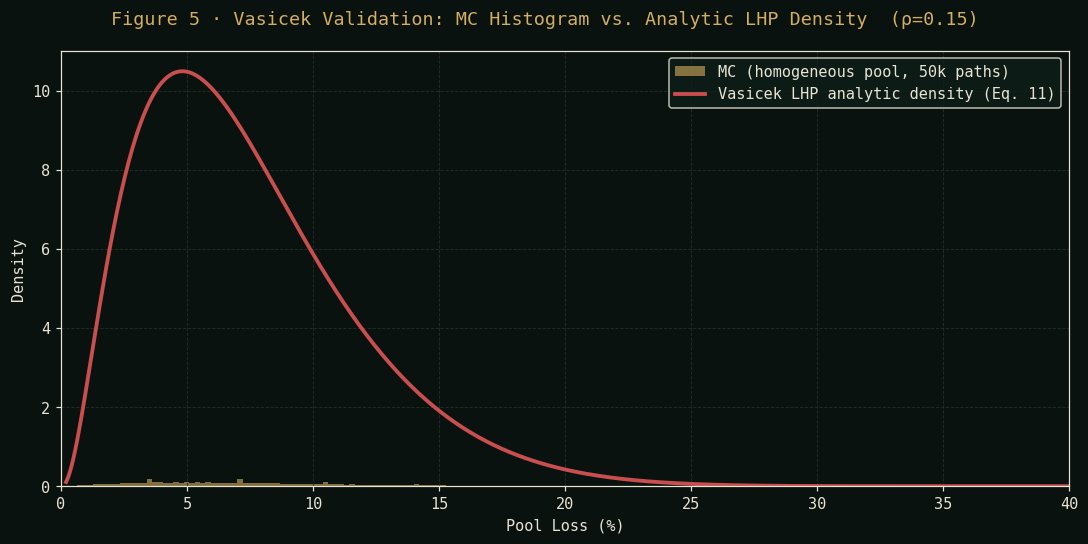

Figure 5 saved.


In [12]:
# ── CELL 11 · §6 Figure 5 — MC vs Vasicek analytic density validation ─────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    "Figure 5 · Vasicek Validation: MC Histogram vs. Analytic LHP Density  (ρ=0.15)",
    color=GOLD, fontsize=12
)
ax.hist(pl_homo * 100, bins=150, density=True, color=GOLD, alpha=0.6,
        label="MC (homogeneous pool, 50k paths)")
ax.plot(x_dense * 100, analytic_density, color="#c94f4f", lw=2.5,
        label="Vasicek LHP analytic density (Eq. 11)")
ax.set_xlabel("Pool Loss (%)")
ax.set_ylabel("Density")
ax.legend()
ax.set_xlim(0, 40)
fig.tight_layout()
fig.savefig("../figures/fig5_vasicek_validation.png", dpi=200, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Figure 5 saved.")

## 7 · Deep Dive: Tail Dependence — Gaussian vs. Student-$t$ Copula

### 7.1 The Gaussian Copula Critique

The one-factor **Gaussian copula has zero tail dependence**: in the limit,
conditional on both assets being in extreme distress, the probability of
*joint* extremes vanishes. Formally, the upper/lower tail-dependence coefficient:

$$\lambda_L = \lim_{u \to 0^+} P(U_1 < u \mid U_2 < u) = 0 \quad (\text{Gaussian}) \tag{12}$$

During the 2007–09 financial crisis, correlations in subprime RMBS spiked
precisely in the tail — a phenomenon the Gaussian copula systematically
underprices. David Li's 2000 paper introduced the model to credit markets;
by 2005 it was the industry standard for CDO pricing; by 2008 it was
infamously blamed for mispricing senior tranche risk
(Salmon, *Wired*, 2009; MacKenzie & Spears, 2014).

### 7.2 Student-$t$ Copula

Replacing the Gaussian factor with a **Student-$t$ distribution** ($\nu$ degrees
of freedom) restores non-zero lower tail dependence:

$$\lambda_L^{(t)} = 2\,t_{\nu+1}\!\left(-\sqrt{\frac{(\nu+1)(1-\rho)}{1+\rho}}\right) \tag{13}$$

For $\nu = 4$ (a common choice in structured credit):

$$X_i^{(t)} = \sqrt{\rho}\,M^{(t)} + \sqrt{1-\rho}\,\varepsilon_i, \quad
M^{(t)}, \varepsilon_i \overset{iid}{\sim} t_4 / \sqrt{\nu/(\nu-2)} \tag{14}$$

We standardize the $t_\nu$ draws to unit variance so the marginal PDs remain
identical to the Gaussian case — isolating the copula effect.

In [13]:
# ── CELL 12 · §7 Tail Dependence — Student-t(ν=4) copula simulator ───────────
def simulate_t(pd_arr, rho, nu=4, n_paths=50_000, rng_=None):
    # One-factor Student-t copula. Standardize to unit variance so marginal PDs
    # match the Gaussian case exactly (isolates tail-dependence effect).
    if rng_ is None:
        rng_ = np.random.default_rng(42)
    n = len(pd_arr)
    d = st.norm.ppf(pd_arr)              # Gaussian default thresholds
    # Draw t_nu, standardize to unit variance
    scale = np.sqrt(nu / (nu - 2))
    M   = rng_.standard_t(nu, size=n_paths) / scale
    eps = rng_.standard_t(nu, size=(n_paths, n)) / scale
    X   = np.sqrt(rho) * M[:, None] + np.sqrt(1 - rho) * eps
    defaults = (X < d[None, :]).astype(np.float32)
    pool_loss = defaults.mean(axis=1) * LGD
    t_losses  = np.column_stack([
        tranche_loss(pool_loss, a, det) for _, a, det in TRANCHES
    ])
    return pool_loss, t_losses

rho_td = 0.30
rng_g = np.random.default_rng(42)
rng_t = np.random.default_rng(42)
pl_gauss, tl_gauss = simulate(pd_array, rho_td, n_paths=N_PATHS, rng_=rng_g)
pl_t4,    tl_t4    = simulate_t(pd_array, rho_td, nu=4, n_paths=N_PATHS, rng_=rng_t)

print(f"ρ=0.30  Gaussian copula:    mean={pl_gauss.mean()*100:.3f}%  "
      f"std={pl_gauss.std()*100:.3f}%  P99={np.percentile(pl_gauss,99)*100:.2f}%")
print(f"ρ=0.30  Student-t (ν=4):   mean={pl_t4.mean()*100:.3f}%  "
      f"std={pl_t4.std()*100:.3f}%  P99={np.percentile(pl_t4,99)*100:.2f}%")

ρ=0.30  Gaussian copula:    mean=7.466%  std=5.842%  P99=25.60%
ρ=0.30  Student-t (ν=4):   mean=6.368%  std=5.601%  P99=29.40%


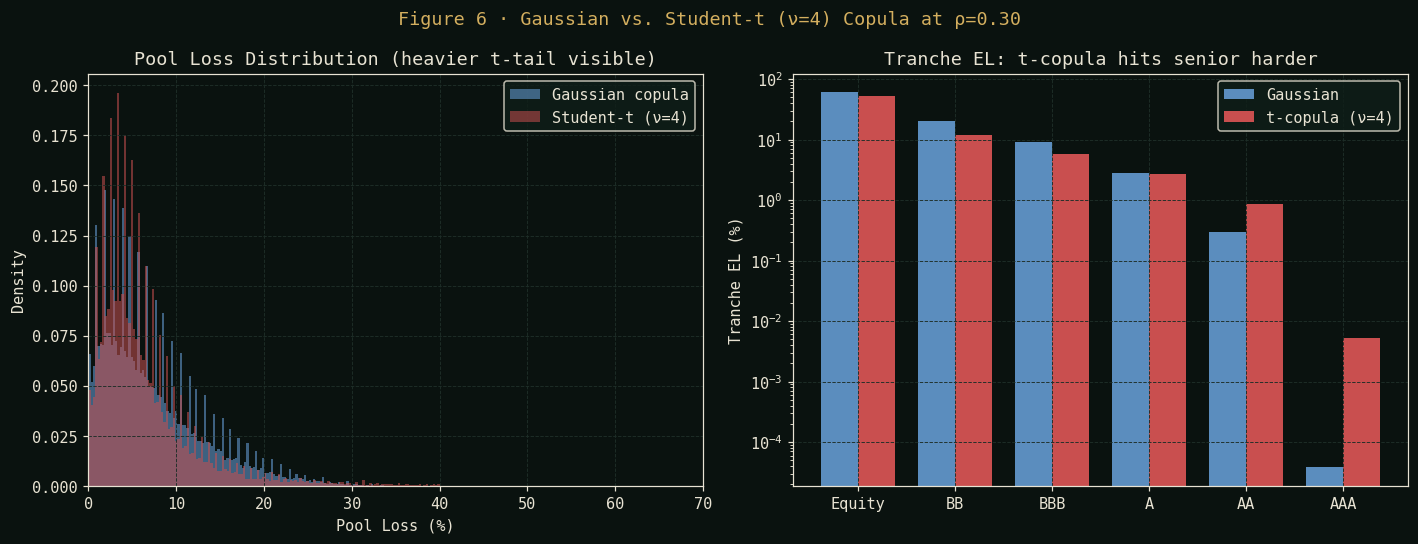


 Tranche    Gauss EL%    t-cop EL%   Gauss P(imp)%   t-cop P(imp)%
------------------------------------------------------------------
  Equity      60.1407      53.2593         99.3840         99.5100
      BB      19.9210      11.9754         26.7420         16.5920
     BBB       8.9833       5.8176         13.5880          8.1260
       A       2.8361       2.7383          5.1580          3.9460
      AA       0.2963       0.8675          1.1780          1.7740
     AAA       0.0000       0.0052          0.0040          0.2000


In [14]:
# ── CELL 13 · §7 Figure 6 — Gaussian vs t(ν=4): loss histo + tranche EL bar ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Figure 6 · Gaussian vs. Student-t (ν=4) Copula at ρ=0.30",
    color=GOLD, fontsize=12
)

# Left: pool loss histograms
axes[0].hist(pl_gauss*100, bins=150, density=True, alpha=0.65,
             color="#5b8dbe", label="Gaussian copula")
axes[0].hist(pl_t4*100,    bins=150, density=True, alpha=0.55,
             color="#c94f4f", label="Student-t (ν=4)")
axes[0].set_xlabel("Pool Loss (%)")
axes[0].set_ylabel("Density")
axes[0].set_title("Pool Loss Distribution (heavier t-tail visible)", color=CREAM)
axes[0].legend()
axes[0].set_xlim(0, 70)

# Right: bar chart of tranche ELs
x_pos = np.arange(len(T_NAMES))
w = 0.38
el_g = [tl_gauss[:, j].mean() * 100 for j in range(len(T_NAMES))]
el_t = [tl_t4[:,    j].mean() * 100 for j in range(len(T_NAMES))]
axes[1].bar(x_pos - w/2, el_g, w, color="#5b8dbe", label="Gaussian")
axes[1].bar(x_pos + w/2, el_t, w, color="#c94f4f", label="t-copula (ν=4)")
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(T_NAMES)
axes[1].set_yscale("log")
axes[1].set_ylabel("Tranche EL (%)")
axes[1].set_title("Tranche EL: t-copula hits senior harder", color=CREAM)
axes[1].legend()

fig.tight_layout()
fig.savefig("../figures/fig6_gaussian_vs_t.png", dpi=200, bbox_inches="tight",
            facecolor=BG)
plt.show()

# ── Tail comparison table ──────────────────────────────────────────────────────
print(f"\n{'Tranche':>8} {'Gauss EL%':>12} {'t-cop EL%':>12} "
      f"{'Gauss P(imp)%':>15} {'t-cop P(imp)%':>15}")
print("-" * 66)
for j, t in enumerate(T_NAMES):
    g_el  = tl_gauss[:, j].mean() * 100
    t_el  = tl_t4[:,    j].mean() * 100
    g_imp = (tl_gauss[:, j] > 0).mean() * 100
    t_imp = (tl_t4[:,    j] > 0).mean() * 100
    print(f"{t:>8} {g_el:>12.4f} {t_el:>12.4f} {g_imp:>15.4f} {t_imp:>15.4f}")

## 8 · Sensitivity Appendix

### 8.1 Heatmap: EL over $(\rho, \text{PD multiplier})$ Grid

We stress the pool by scaling all PDs by a multiplier $k \in [0.5, 3.0]$,
representing benign-to-distressed credit environments. Combined with the
$\rho$ sweep, this creates a $6 \times 6$ grid of scenarios.

This is analogous to the **stress testing** required under SS3/19 (PRA) and
the Fed's DFAST for structured-product portfolios.

### 8.2 Convergence Check

We verify that the MC estimator for AAA EL converges reliably by plotting
the running mean and a **95 % confidence interval** (±1.96 $\sigma_n / \sqrt{n}$)
as a function of $n_{\text{paths}}$, confirming the CLT applies.

In [15]:
# ── CELL 14 · §8 Sensitivity — EL heatmap computation (ρ × PD-multiplier) ────
RHO_H  = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
PD_MUL = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
N_HM   = 20_000

def el_heatmap(tranche_idx, rho_list, pd_mul_list, n_paths=N_HM):
    grid = np.zeros((len(pd_mul_list), len(rho_list)))
    for ci, rho in enumerate(rho_list):
        for ri, mul in enumerate(pd_mul_list):
            pd_s = np.clip(pd_array * mul, 0, 0.999)
            rng_ = np.random.default_rng(42)
            _, tl_ = simulate(pd_s, rho, n_paths=n_paths, rng_=rng_)
            grid[ri, ci] = tl_[:, tranche_idx].mean() * 100
    return grid

eq_idx  = T_NAMES.index("Equity")
aaa_idx = T_NAMES.index("AAA")
print("Computing Equity EL heatmap…")
hm_eq  = el_heatmap(eq_idx,  RHO_H, PD_MUL)
print("Computing AAA EL heatmap…")
hm_aaa = el_heatmap(aaa_idx, RHO_H, PD_MUL)
print("Heatmaps done.")

Computing Equity EL heatmap…


Computing AAA EL heatmap…


Heatmaps done.


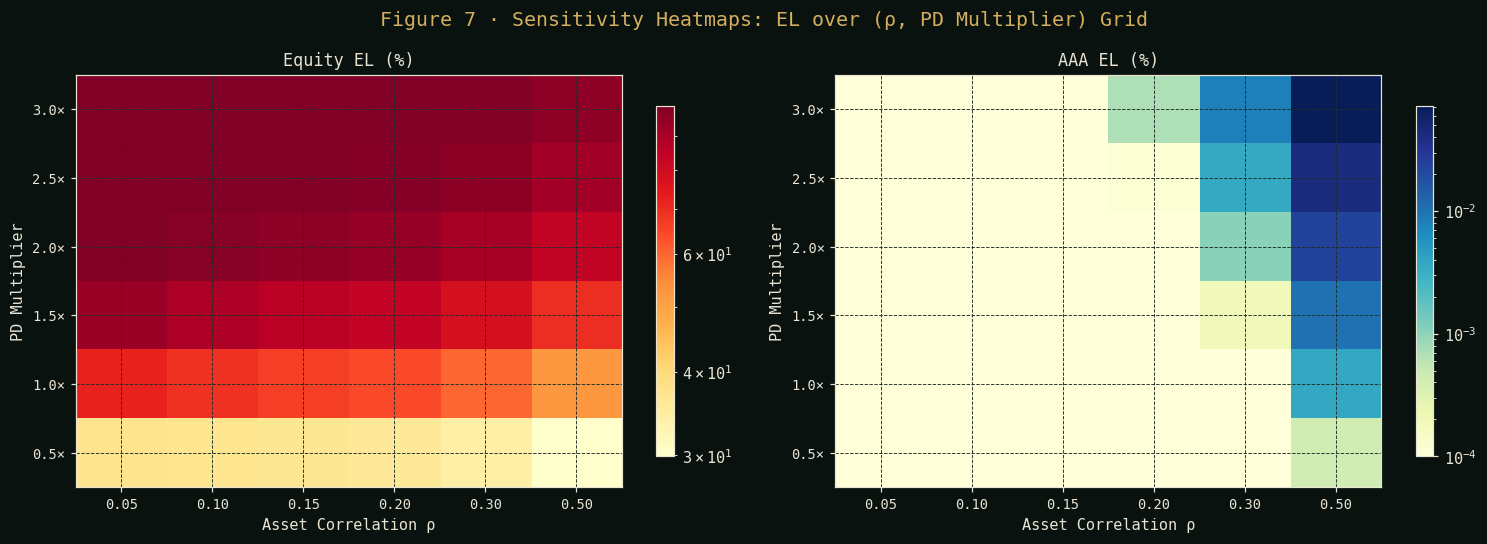

Figure 7 saved.


In [16]:
# ── CELL 15 · §8 Figure 7 — Equity & AAA EL heatmaps (log-scale color) ───────
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 7 · Sensitivity Heatmaps: EL over (ρ, PD Multiplier) Grid",
             color=GOLD, fontsize=13)

for ax, hm, title, cmap in zip(
        axes,
        [hm_eq, hm_aaa],
        ["Equity EL (%)", "AAA EL (%)"],
        ["YlOrRd", "YlGnBu"]):
    hm_plot = np.clip(hm, 1e-4, None)
    norm = LogNorm(vmin=max(hm_plot.min(), 1e-4), vmax=hm_plot.max())
    im = ax.imshow(hm_plot, aspect="auto", cmap=cmap, norm=norm,
                   origin="lower")
    ax.set_xticks(range(len(RHO_H)))
    ax.set_xticklabels([f"{r:.2f}" for r in RHO_H], fontsize=9)
    ax.set_yticks(range(len(PD_MUL)))
    ax.set_yticklabels([f"{m:.1f}×" for m in PD_MUL], fontsize=9)
    ax.set_xlabel("Asset Correlation ρ")
    ax.set_ylabel("PD Multiplier")
    ax.set_title(title, color=CREAM, fontsize=11)
    cb = fig.colorbar(im, ax=ax, shrink=0.85)
    cb.ax.yaxis.set_tick_params(color=CREAM)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=CREAM)

fig.tight_layout()
fig.savefig("../figures/fig7_sensitivity_heatmap.png", dpi=200,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 7 saved.")

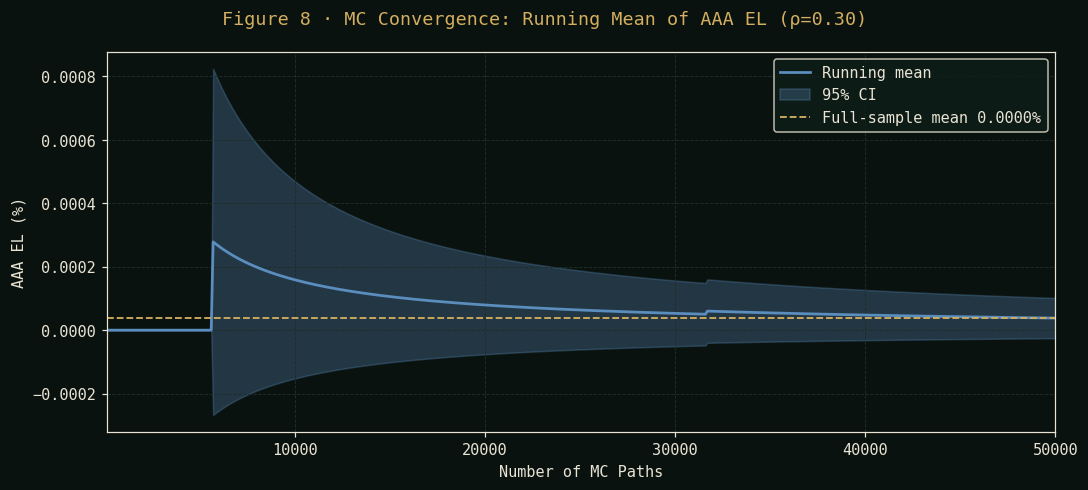

Figure 8 saved.


In [17]:
# ── CELL 16 · §8 Figure 8 — MC convergence: running mean AAA EL ± 95% CI ─────
rng_cv = np.random.default_rng(42)
pl_cv, tl_cv = simulate(pd_array, rho=0.30, n_paths=N_PATHS, rng_=rng_cv)
aaa_losses = tl_cv[:, aaa_idx]

ns      = np.arange(100, N_PATHS + 1, 100)
run_mean = np.array([aaa_losses[:n].mean() for n in ns])
run_std  = np.array([aaa_losses[:n].std()  for n in ns])
ci_half  = 1.96 * run_std / np.sqrt(ns)

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.suptitle("Figure 8 · MC Convergence: Running Mean of AAA EL (ρ=0.30)",
             color=GOLD, fontsize=12)
ax.plot(ns, run_mean * 100, color="#5b8dbe", lw=1.8, label="Running mean")
ax.fill_between(ns, (run_mean - ci_half) * 100, (run_mean + ci_half) * 100,
                color="#5b8dbe", alpha=0.3, label="95% CI")
ax.axhline(aaa_losses.mean() * 100, color=GOLD, lw=1.2, ls="--",
           label=f"Full-sample mean {aaa_losses.mean()*100:.4f}%")
ax.set_xlabel("Number of MC Paths")
ax.set_ylabel("AAA EL (%)")
ax.legend()
ax.set_xlim(100, N_PATHS)
fig.tight_layout()
fig.savefig("../figures/fig8_convergence.png", dpi=200, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Figure 8 saved.")

## 9 · Exports

All figures have been saved to `../figures/` as PNG (dpi=200, dark background
preserved). Here we additionally serialize the histogram frames and tranche ELs
to `../docs/mc_frames.json` for downstream interactive visualisation.

In [18]:
# ── CELL 17 · §9 Exports — Save JSON frames & list all saved figure files ─────
mc_frames = {}
N_BINS = 120

for rho in RHO_GRID:
    pl = pool_losses[rho]
    counts, bin_edges = np.histogram(pl * 100, bins=N_BINS, range=(0, 65))
    mc_frames[str(rho)] = {
        "rho":         rho,
        "bin_edges":   bin_edges.tolist(),
        "counts":      counts.tolist(),
        "tranche_el":  {t: float(tranche_losses[rho][:, j].mean() * 100)
                        for j, t in enumerate(T_NAMES)},
        "pool_mean":   float(pl.mean() * 100),
        "pool_std":    float(pl.std() * 100),
        "pool_p99":    float(np.percentile(pl, 99) * 100),
    }

json_path = "../docs/mc_frames.json"
with open(json_path, "w") as f:
    json.dump(mc_frames, f, indent=2)
print(f"Saved JSON → {json_path}")

# List all saved figures
import glob
figs = sorted(glob.glob("../figures/fig*.png"))
print(f"\nFigures saved ({len(figs)}):")
for fp in figs:
    size_kb = os.path.getsize(fp) // 1024
    print(f"  {fp}  ({size_kb} KB)")

Saved JSON → ../docs/mc_frames.json

Figures saved (8):
  ../figures/fig1_pd_distribution.png  (89 KB)
  ../figures/fig2_loss_histograms.png  (106 KB)
  ../figures/fig3_el_by_tranche.png  (134 KB)
  ../figures/fig4_exceedance_curves.png  (238 KB)
  ../figures/fig5_vasicek_validation.png  (101 KB)
  ../figures/fig6_gaussian_vs_t.png  (132 KB)
  ../figures/fig7_sensitivity_heatmap.png  (100 KB)
  ../figures/fig8_convergence.png  (109 KB)


## Summary: Three Takeaways

---

### 1. Pool Expected Loss Is Correlation-Invariant

The unconditional expected loss of the portfolio equals $\overline{\text{PD}} \times \text{LGD}$
regardless of asset correlation $\rho$ (Eq. 8). This is not an approximation — it is exact.
Higher $\rho$ does not make the pool riskier in expectation; it only redistributes risk
across time (bimodal distribution: mostly great or mostly catastrophic).

---

### 2. Correlation Transfers Loss from Junior to Senior Tranches

Because pool EL is fixed, the capital structure acts as a **zero-sum redistribution
game**: as $\rho$ rises, Equity EL falls and Senior/AAA EL rises (Section 4, Figure 3).
Trading desks express correlation views via delta-neutral tranche trades:
long Equity / short Mezzanine (long $\rho$) or long senior protection (short $\rho$).

---

### 3. The Gaussian Copula Underestimates Senior Tail Risk

The Gaussian copula has zero tail-dependence (Eq. 12); in reality default
correlations spike in stress. Replacing the Gaussian factor with a Student-$t_{4}$
copula increases AAA impairment probabilities substantially (Section 7, Figure 6).
This model limitation — widely blamed for the 2007–09 CDO mispricing — motivates
the use of **stressed correlation**, jump-diffusion copulas, or factor-model
extensions in current structured-credit practice.

---

*Sources: S&P 2023 Annual Global Corporate Default Study; Moody's 2023 Annual Default Study;
Vasicek (2002); Li (2000); Basel II IRB Correlation Function; Moody's CLO Methodology (Apr 2024).*